# Air Quality Index (AQI) Analysis — India (2015–2020)

**Course Project | Data Analytics**

---

## 1. Introduction

This project analyses **Air Quality Index (AQI)** data from India's **Central Pollution Control Board (CPCB)** to understand how air quality changes across 26 major cities from January 2015 to July 2020. The six core pollutants examined are **PM2.5, PM10, NO₂, SO₂, CO, and O₃**. The workflow covers data ingestion, cleaning, feature engineering, exploratory analysis, and evidence-based findings.

## 2. Research Questions

| # | Research Question |
|---|-------------------|
| **RQ1** | How does AQI change over time — are there clear daily, monthly, seasonal, or year-on-year patterns? |
| **RQ2** | Is there a relationship between specific pollutants (PM2.5, PM10, NO₂, SO₂, CO, O₃) and the AQI category? |
| **RQ3** | How often does air quality reach unhealthy or hazardous levels, and which cities are most affected? |

## 3. Dataset

- **Source:** *Air Quality Data in India (2015–2020)* by Rohan Rao, compiled from CPCB — [Kaggle link](https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india)
- **File used:** `city_day.csv` — one row per city per day
- **Coverage:** 26 cities · 29,531 rows · Jan 2015 – Jul 2020
- **Columns:** `City, Date, PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, Xylene, AQI, AQI_Bucket`

---
## 4. Setup — Libraries & Global Constants

In [3]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import zipfile
from pathlib import Path

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Plot theme ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "figure.autolayout": True,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Output directory ──────────────────────────────────────────────────────────
FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
# Kaggle input path; falls back to local path if not on Kaggle
KAGGLE_PATH = Path("/kaggle/input/datasets/rohanrao/air-quality-data-in-india/city_day.csv")
LOCAL_PATH  = Path("data/city_day.csv")
DATA_PATH   = KAGGLE_PATH if KAGGLE_PATH.exists() else LOCAL_PATH

# Six core pollutants used throughout the analysis
POLLUTANTS = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]

# Eight major cities highlighted in city-level charts
FOCUS = ["Delhi", "Mumbai", "Kolkata", "Chennai",
         "Hyderabad", "Bengaluru", "Ahmedabad", "Lucknow"]

# CPCB AQI category order (ordinal: Good → Severe)
CAT_ORDER = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]

# Matching colour palette for AQI categories
CAT_COLORS = ["#2ca02c", "#a6d854", "#ffd92f", "#fc8d62", "#e34a33", "#7f0000"]

print(f"Data path resolved to: {DATA_PATH}")
print("Setup complete.")

Data path resolved to: /kaggle/input/datasets/rohanrao/air-quality-data-in-india/city_day.csv
Setup complete.


---
## 5. Load the Dataset

In [4]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=["Date"])

print(f"Shape        : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Cities       : {df_raw['City'].nunique()}")
print(f"Date range   : {df_raw['Date'].min().date()} → {df_raw['Date'].max().date()}")
print(f"\nCity list:\n{sorted(df_raw['City'].unique())}")
df_raw.head()

Shape        : 29,531 rows × 16 columns
Cities       : 26
Date range   : 2015-01-01 → 2020-07-01

City list:
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       24933 non-null  float64       
 3   PM10        18391 non-null  float64       
 4   NO          25949 non-null  float64       
 5   NO2         25946 non-null  float64       
 6   NOx         25346 non-null  float64       
 7   NH3         19203 non-null  float64       
 8   CO          27472 non-null  float64       
 9   SO2         25677 non-null  float64       
 10  O3          25509 non-null  float64       
 11  Benzene     23908 non-null  float64       
 12  Toluene     21490 non-null  float64       
 13  Xylene      11422 non-null  float64       
 14  AQI         24850 non-null  float64       
 15  AQI_Bucket  24850 non-null  object        
dtypes: datetime64[ns](1), 

---
## 6. Data Preparation & Cleaning

This is real CPCB monitoring data and therefore contains missing values. The cleaning pipeline:

1. **Profile missing values** — quantify gaps per column.
2. **Select columns** — keep the six target pollutants + `AQI` + `AQI_Bucket`; drop rarely-reported trace columns (`NO`, `NOx`, `NH3`, `Benzene`, `Toluene`, `Xylene`).
3. **Drop rows with no AQI** — the target variable; rows without it cannot be used for AQI-based analysis.
4. **Outlier detection & capping** — values above the CPCB maximum of 500 are flagged and capped in a separate column to preserve both raw and cleaned data.
5. **Feature engineering** — derive `Year`, `Month`, `Season`, `DayOfWeek`, and `Unhealthy` flag.
6. **Imputation note** — remaining per-pollutant NaNs are left as-is; all correlation and aggregation functions use pairwise-complete observations, which is appropriate for exploratory analysis.

### Table 1 — Missing Values Before Cleaning

In [6]:
miss = (
    df_raw.isnull()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "Missing_count", "mean": "Missing_%"})
)
miss["Missing_%"] = (miss["Missing_%"] * 100).round(1)
miss = miss.sort_values("Missing_%", ascending=False)
miss.to_csv(FIGDIR / "table_01_missing_values.csv")
miss

,Missing_count,Missing_%
Xylene,18109.0,61.3
PM10,11140.0,37.7
NH3,10328.0,35.0
Toluene,8041.0,27.2
Benzene,5623.0,19.0
AQI,4681.0,15.9
AQI_Bucket,4681.0,15.9
PM2.5,4598.0,15.6
NOx,4185.0,14.2
O3,4022.0,13.6


### Step-by-Step Cleaning Pipeline

In [7]:
# ── Step 1: Select relevant columns ───────────────────────────────────────────
keep_cols = ["City", "Date"] + POLLUTANTS + ["AQI", "AQI_Bucket"]
df = df_raw[keep_cols].copy()

# ── Step 2: Drop rows where AQI (the target) is missing ───────────────────────
n_before = len(df)
df = df.dropna(subset=["AQI"]).reset_index(drop=True)
print(f"Step 2 — Dropped {n_before - len(df):,} rows with missing AQI; "
      f"{len(df):,} rows remain.")

# ── Step 3: Outlier detection — CPCB ceiling is 500 ──────────────────────────
n_outliers = (df["AQI"] > 500).sum()
print(f"Step 3 — Found {n_outliers:,} rows with AQI > 500 (above CPCB maximum).")
outlier_cities = df.loc[df["AQI"] > 500, "City"].value_counts()
print("  Outlier rows by city:")
print(outlier_cities.to_string())

# Preserve raw AQI; create a capped column for cleaner aggregate statistics
df["AQI_raw"]   = df["AQI"].copy()
df["AQI_capped"] = df["AQI"].clip(upper=500)  # used in sensitivity analyses

# ── Step 4: Feature engineering ───────────────────────────────────────────────
df["Year"]      = df["Date"].dt.year
df["Month"]     = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.day_name()

def assign_season(month: int) -> str:
    """Map calendar month to Indian meteorological season."""
    if month in (12, 1, 2):   return "Winter"
    if month in (3, 4, 5):    return "Summer"
    if month in (6, 7, 8, 9): return "Monsoon"
    return "Post-Monsoon"

df["Season"] = df["Month"].map(assign_season)

# ── Step 5: Ordered categorical for AQI_Bucket ────────────────────────────────
df["AQI_Bucket"] = pd.Categorical(df["AQI_Bucket"], categories=CAT_ORDER, ordered=True)

# ── Step 6: Boolean flag — 'Unhealthy' = AQI > 200 (Poor / Very Poor / Severe)
df["Unhealthy"] = df["AQI"] > 200

print(f"\nCleaning complete. Final shape: {df.shape}")
print(f"AQI categories (ordered): {CAT_ORDER}")
df.head()

Step 2 — Dropped 4,681 rows with missing AQI; 24,850 rows remain.
Step 3 — Found 543 rows with AQI > 500 (above CPCB maximum).
  Outlier rows by city:
City
Ahmedabad     412
Delhi          48
Patna          25
Gurugram       22
Lucknow        15
Jorapokhar      7
Amritsar        4
Hyderabad       4
Talcher         4
Guwahati        2

Cleaning complete. Final shape: (24850, 17)
AQI categories (ordered): ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']


,City,Date,PM2.5,PM10,NO2,SO2,CO,O3,AQI,AQI_Bucket,AQI_raw,AQI_capped,Year,Month,DayOfWeek,Season,Unhealthy
0,Ahmedabad,2015-01-29,83.13,NaN,28.71,49.52,6.93,59.76,209.0,Poor,209.0,209.0,2015,1,Thursday,Winter,True
1,Ahmedabad,2015-01-30,79.84,NaN,28.68,48.49,13.85,97.07,328.0,Very Poor,328.0,328.0,2015,1,Friday,Winter,True
2,Ahmedabad,2015-01-31,94.52,NaN,32.66,67.39,24.39,111.33,514.0,Severe,514.0,500.0,2015,1,Saturday,Winter,True
3,Ahmedabad,2015-02-01,135.99,NaN,42.08,75.23,43.48,102.70,782.0,Severe,782.0,500.0,2015,2,Sunday,Winter,True
4,Ahmedabad,2015-02-02,178.33,NaN,35.31,55.04,54.56,107.38,914.0,Severe,914.0,500.0,2015,2,Monday,Winter,True


### Reference — CPCB National AQI Scale

India's CPCB uses a six-level AQI scale. This project treats **Poor, Very Poor, and Severe** (AQI > 200) as *"unhealthy or hazardous"* for RQ3.

In [8]:
cpcb_scale = pd.DataFrame({
    "AQI Range" : ["0–50", "51–100", "101–200", "201–300", "301–400", "401–500"],
    "Category"  : CAT_ORDER,
    "Health Concern": [
        "Minimal impact",
        "Minor breathing discomfort to sensitive people",
        "Breathing discomfort to people with lung/heart disease",
        "Breathing discomfort to most people on prolonged exposure",
        "Respiratory illness on prolonged exposure",
        "Affects healthy people; serious impact on sensitive people",
    ],
    "Unhealthy Flag": ["No", "No", "No", "Yes", "Yes", "Yes"],
})
cpcb_scale

,AQI Range,Category,Health Concern,Unhealthy Flag
0,0–50,Good,Minimal impact,No
1,51–100,Satisfactory,Minor breathing discomfort to sensitive people,No
2,101–200,Moderate,Breathing discomfort to people with lung/heart...,No
3,201–300,Poor,Breathing discomfort to most people on prolong...,Yes
4,301–400,Very Poor,Respiratory illness on prolonged exposure,Yes
5,401–500,Severe,Affects healthy people; serious impact on sens...,Yes


### Table 2 — Descriptive Statistics (AQI & Pollutants)

> **Note on Ahmedabad outliers:** The raw AQI max of 2,049 is well above the CPCB ceiling of 500 and reflects sensor/data-quality issues rather than real air pollution. The `AQI_capped` column clips these values for use in tables and comparisons that would otherwise be distorted.

In [9]:
# Summary stats for both raw and capped AQI to show the outlier impact clearly
stats_cols = ["AQI", "AQI_capped"] + POLLUTANTS
summary = (
    df[stats_cols]
    .describe()
    .T
    .round(1)
    [["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
)
summary.to_csv(FIGDIR / "table_02_summary_stats.csv")
summary

,count,mean,std,min,25%,50%,75%,max
AQI,24850.0,166.5,140.7,13.0,81.0,118.0,208.0,2049.0
AQI_capped,24850.0,160.9,113.2,13.0,81.0,118.0,208.0,500.0
PM2.5,24172.0,67.5,63.1,0.0,29.0,48.8,80.9,914.9
PM10,17764.0,118.5,89.5,0.0,56.8,96.2,150.2,917.1
NO2,24459.0,29.0,24.6,0.0,11.9,22.1,38.2,362.2
SO2,24245.0,14.4,17.4,0.0,5.7,9.2,15.1,186.1
CO,24405.0,2.3,7.1,0.0,0.6,0.9,1.5,175.8
O3,24043.0,34.9,21.7,0.0,19.2,31.2,46.1,257.7


### Table 3 — City-Level Summary Statistics (All 26 Cities)

In [10]:
city_stats = (
    df.groupby("City")
    .agg(
        Days         =("AQI", "size"),
        Mean_AQI     =("AQI_capped", "mean"),
        Median_AQI   =("AQI_capped", "median"),
        Std_AQI      =("AQI_capped", "std"),
        Max_AQI_raw  =("AQI", "max"),
        Unhealthy_pct=("Unhealthy", "mean"),
    )
    .assign(Unhealthy_pct=lambda x: (x["Unhealthy_pct"] * 100))
    .round(1)
    .sort_values("Mean_AQI", ascending=False)
)
city_stats.to_csv(FIGDIR / "table_03_city_stats.csv")
city_stats

,Days,Mean_AQI,Median_AQI,Std_AQI,Max_AQI_raw,Unhealthy_pct
City,,,,,,
Ahmedabad,1334,356.0,384.5,138.5,2049.0,81.9
Delhi,1999,258.1,257.0,116.0,716.0,65.1
Patna,1459,240.1,215.0,120.7,619.0,53.5
Gurugram,1453,223.7,208.0,115.4,891.0,51.8
Lucknow,1893,217.5,198.0,115.4,707.0,49.4
Talcher,698,172.7,128.5,104.3,570.0,29.4
Jorapokhar,771,158.7,133.0,82.3,604.0,22.4
Brajrajnagar,713,150.3,122.0,70.4,355.0,21.9
Kolkata,754,140.6,94.0,104.5,475.0,26.3


---
## 7. RQ1 — How Does AQI Change Over Time?

We examine four temporal dimensions:
- **Fig 1:** Monthly trend line per city (2015–2020), including COVID-19 lockdown annotation
- **Fig 2:** Year-on-year average AQI by city
- **Fig 3:** AQI distribution by AQI bucket (how many days in each category)
- **Fig 4:** Seasonal cycle — average AQI by calendar month
- **Fig 5:** Average AQI by season
- **Fig 6:** Average AQI by day of week

### Fig 1 — Monthly AQI Trend by City (2015–2020)

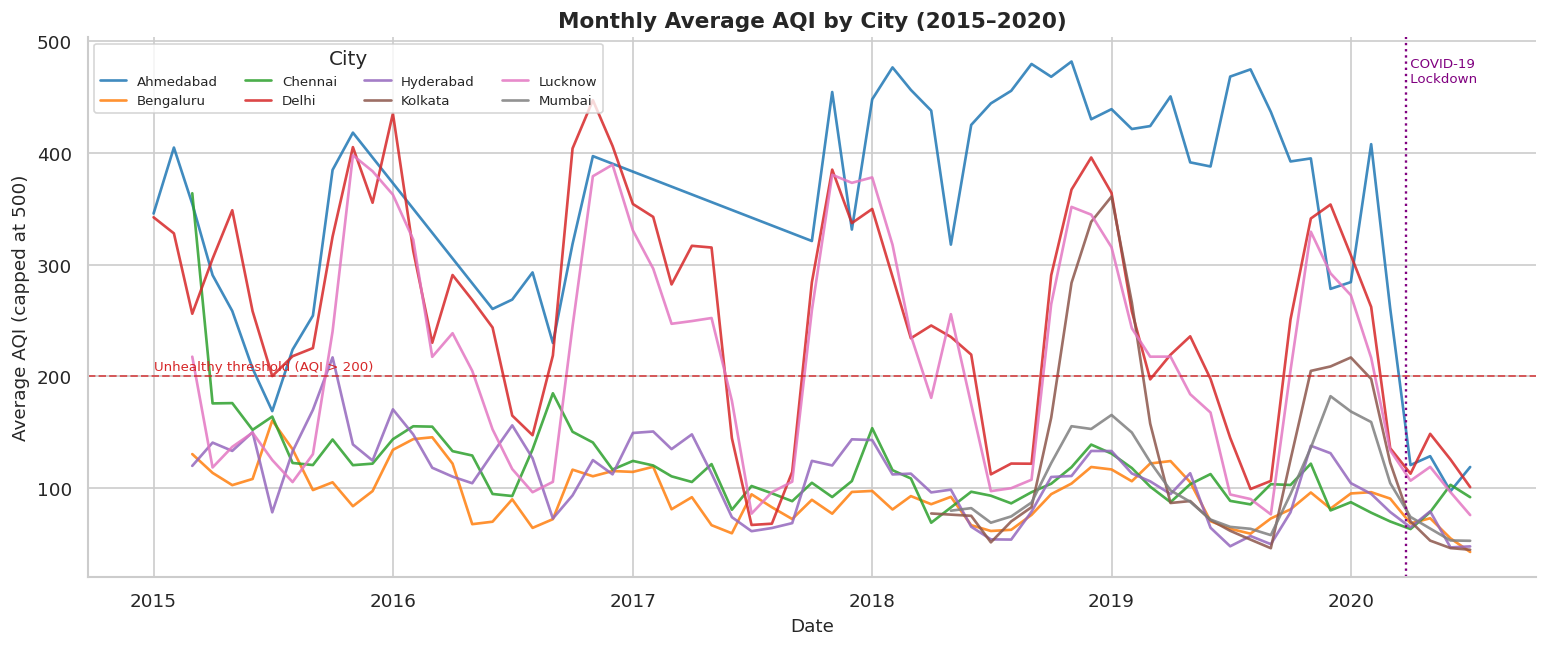

Interpretation: Northern cities (Delhi, Lucknow) consistently exceed the unhealthy threshold each winter. A visible dip across all cities coincides with the March 2020 COVID-19 lockdown, when traffic and industry halted.


In [11]:
sub = df[df["City"].isin(FOCUS)].copy()

monthly = (
    sub.set_index("Date")
    .groupby("City")["AQI_capped"]
    .resample("MS")
    .mean()
    .reset_index()
    .rename(columns={"AQI_capped": "AQI"})
)

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.lineplot(data=monthly, x="Date", y="AQI", hue="City",
             lw=1.6, alpha=0.85, ax=ax)

# Unhealthy threshold
ax.axhline(200, ls="--", c="#d62728", lw=1.2, alpha=0.7)
ax.text(monthly["Date"].min(), 206,
        "Unhealthy threshold (AQI > 200)", fontsize=8, color="#d62728")

# COVID-19 lockdown annotation (India: 25 Mar 2020)
lockdown_date = pd.Timestamp("2020-03-25")
ax.axvline(lockdown_date, ls=":", c="purple", lw=1.4)
ax.text(lockdown_date, ax.get_ylim()[1] * 0.92,
        " COVID-19\n Lockdown", fontsize=8, color="purple")

ax.set_title("Monthly Average AQI by City (2015–2020)")
ax.set_xlabel("Date")
ax.set_ylabel("Average AQI (capped at 500)")
ax.legend(title="City", ncol=4, fontsize=8, loc="upper left")
plt.savefig(FIGDIR / "fig01_monthly_trend.png", bbox_inches="tight")
plt.show()
print("Interpretation: Northern cities (Delhi, Lucknow) consistently exceed the unhealthy "
      "threshold each winter. A visible dip across all cities coincides with the March 2020 "
      "COVID-19 lockdown, when traffic and industry halted.")

### Fig 2 — Year-on-Year Average AQI by City

Table 4 — Yearly Average AQI (capped):


City,Ahmedabad,Bengaluru,Chennai,Delhi,Hyderabad,Kolkata,Lucknow,Mumbai
Year,,,,,,,,
2015,283.0,112.6,148.3,297.0,142.8,NaN,199.9,NaN
2016,282.7,105.6,138.6,297.6,123.5,NaN,242.4,NaN
2017,379.8,87.1,104.5,254.8,112.3,NaN,237.3,NaN
2018,443.1,86.3,105.5,248.4,97.6,155.3,233.8,102.6
2019,412.8,91.6,102.9,230.7,94.0,143.9,202.6,108.0
2020,214.7,79.7,80.3,181.7,78.2,117.3,157.1,103.6


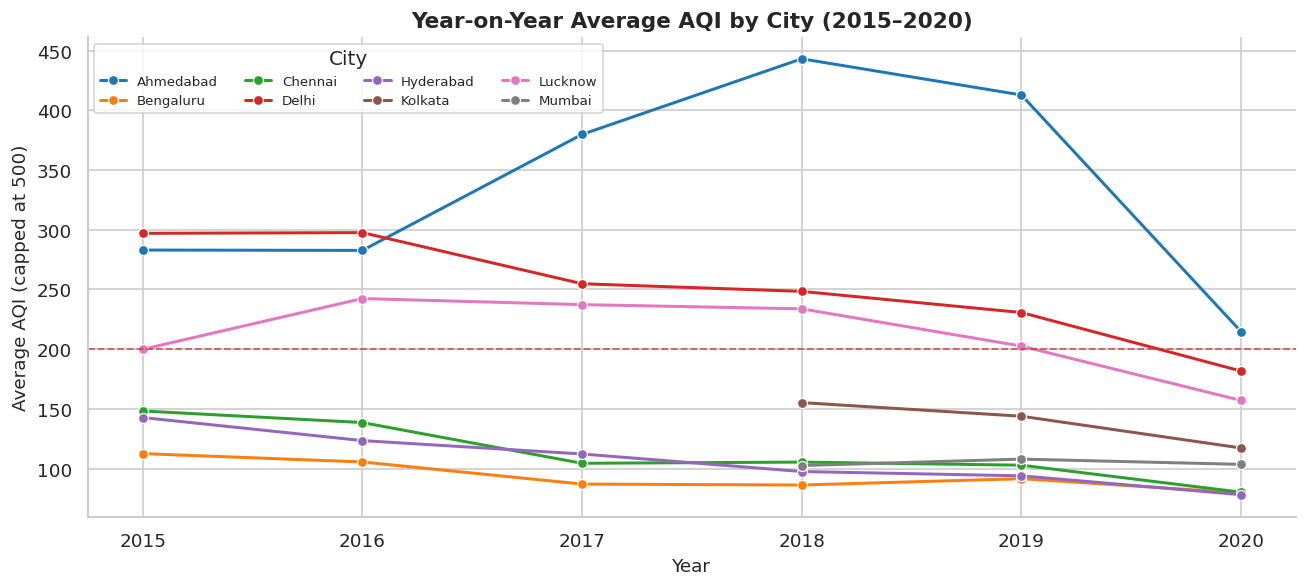

Interpretation: Delhi and Lucknow show the highest and most volatile year-on-year AQI. Southern cities (Bengaluru, Chennai, Hyderabad) remain comparatively stable and low. 2020 values are partial (Jan–Jul only) and reflect the lockdown drop.


In [12]:
# Table 4: Yearly pivot table
yearly_tbl = (
    df[df["City"].isin(FOCUS)]
    .pivot_table(index="Year", columns="City",
                 values="AQI_capped", aggfunc="mean")
    .round(1)
)
yearly_tbl.to_csv(FIGDIR / "table_04_yearly_aqi.csv")
print("Table 4 — Yearly Average AQI (capped):")
display(yearly_tbl)

# Chart
yearly_long = yearly_tbl.reset_index().melt(id_vars="Year",
                                             var_name="City",
                                             value_name="AQI")
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=yearly_long, x="Year", y="AQI", hue="City",
             marker="o", lw=1.8, markersize=6, ax=ax)
ax.axhline(200, ls="--", c="#d62728", lw=1.1, alpha=0.7)
ax.set_title("Year-on-Year Average AQI by City (2015–2020)")
ax.set_xlabel("Year")
ax.set_ylabel("Average AQI (capped at 500)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(title="City", ncol=4, fontsize=8)
plt.savefig(FIGDIR / "fig02_yearly_trend.png", bbox_inches="tight")
plt.show()
print("Interpretation: Delhi and Lucknow show the highest and most volatile year-on-year AQI. "
      "Southern cities (Bengaluru, Chennai, Hyderabad) remain comparatively stable and low. "
      "2020 values are partial (Jan–Jul only) and reflect the lockdown drop.")

### Fig 3 — AQI Bucket Distribution (Count of Days per Category)

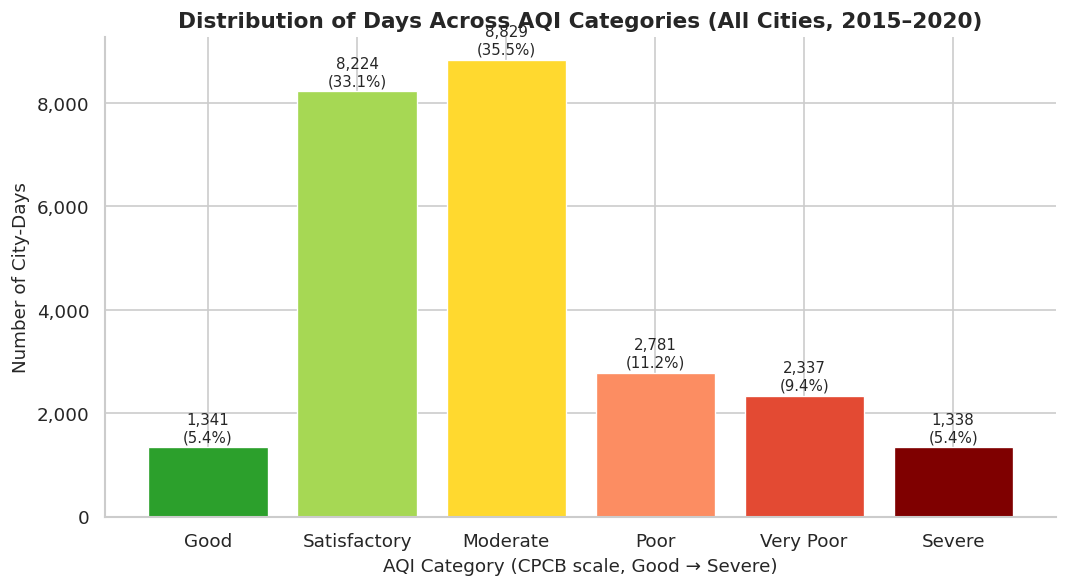

Interpretation: Moderate (35.5%) and Poor (11.2%) are the most common categories. Together, 'Poor', 'Very Poor', and 'Severe' account for 26.0% of all city-days — confirming that unhealthy air is a persistent, not exceptional, condition in India.


In [13]:
bucket_counts = (
    df["AQI_Bucket"]
    .value_counts()
    .reindex(CAT_ORDER)
    .reset_index()
)
bucket_counts.columns = ["Category", "Count"]
bucket_counts["Percentage"] = (bucket_counts["Count"] / bucket_counts["Count"].sum() * 100).round(1)
bucket_counts.to_csv(FIGDIR / "table_05_bucket_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(bucket_counts["Category"],
              bucket_counts["Count"],
              color=CAT_COLORS,
              edgecolor="white",
              linewidth=0.8)

# Annotate bars with count + percentage
for bar, (_, row) in zip(bars, bucket_counts.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60,
            f"{int(row['Count']):,}\n({row['Percentage']}%)",
            ha="center", va="bottom", fontsize=9)

ax.set_title("Distribution of Days Across AQI Categories (All Cities, 2015–2020)")
ax.set_xlabel("AQI Category (CPCB scale, Good → Severe)")
ax.set_ylabel("Number of City-Days")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.savefig(FIGDIR / "fig03_bucket_distribution.png", bbox_inches="tight")
plt.show()
print(f"Interpretation: Moderate ({bucket_counts.loc[2,'Percentage']}%) and Poor "
      f"({bucket_counts.loc[3,'Percentage']}%) are the most common categories. Together, "
      f"'Poor', 'Very Poor', and 'Severe' account for "
      f"{bucket_counts.loc[3:,'Percentage'].sum():.1f}% of all city-days — confirming that "
      f"unhealthy air is a persistent, not exceptional, condition in India.")

### Fig 4 — Seasonal Cycle: Average AQI by Calendar Month

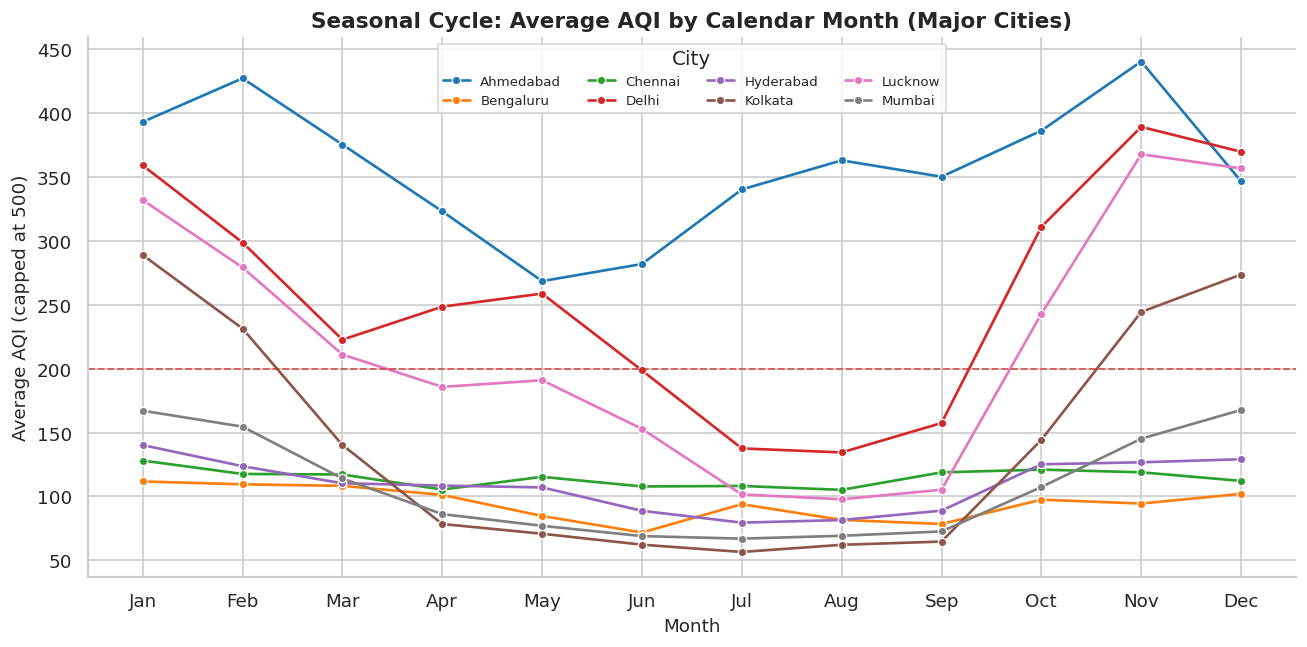

Interpretation: All cities follow a U-shaped seasonal curve — AQI peaks in Dec–Jan (winter) and reaches its lowest in Jul–Aug (monsoon). Northern cities show a much steeper winter spike than southern cities.


In [14]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

mm = (
    sub.groupby(["City", "Month"])["AQI_capped"]
    .mean()
    .reset_index()
    .rename(columns={"AQI_capped": "AQI"})
)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.lineplot(data=mm, x="Month", y="AQI", hue="City",
             marker="o", lw=1.6, markersize=5, ax=ax)
ax.axhline(200, ls="--", c="#d62728", lw=1.1, alpha=0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title("Seasonal Cycle: Average AQI by Calendar Month (Major Cities)")
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI (capped at 500)")
ax.legend(title="City", ncol=4, fontsize=8)
plt.savefig(FIGDIR / "fig04_monthly_cycle.png", bbox_inches="tight")
plt.show()
print("Interpretation: All cities follow a U-shaped seasonal curve — AQI peaks in Dec–Jan "
      "(winter) and reaches its lowest in Jul–Aug (monsoon). Northern cities show a much "
      "steeper winter spike than southern cities.")

### Fig 5 — Average AQI by Season

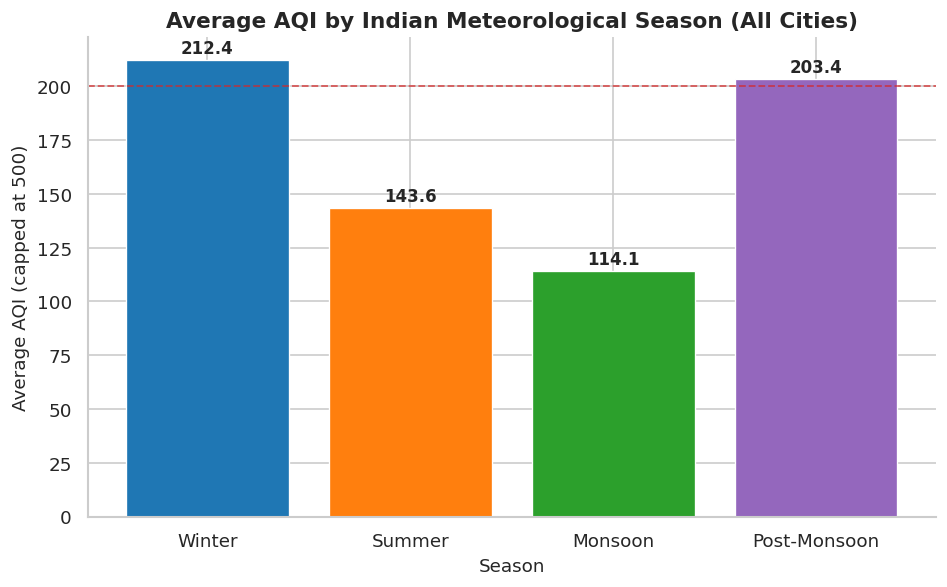

Interpretation: Winter has the highest average AQI due to stable atmospheric conditions (temperature inversions) that trap pollutants near the surface. The monsoon is the cleanest season as rainfall washes out particulate matter.


In [15]:
season_order = ["Winter", "Summer", "Monsoon", "Post-Monsoon"]
season_means = (
    df.groupby("Season")["AQI_capped"]
    .mean()
    .reindex(season_order)
    .reset_index()
    .rename(columns={"AQI_capped": "Mean_AQI"})
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(season_means["Season"],
              season_means["Mean_AQI"],
              color=["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"],
              edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, season_means["Mean_AQI"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f"{val:.1f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(200, ls="--", c="#d62728", lw=1.1, alpha=0.7)
ax.set_title("Average AQI by Indian Meteorological Season (All Cities)")
ax.set_xlabel("Season")
ax.set_ylabel("Average AQI (capped at 500)")
plt.savefig(FIGDIR / "fig05_season.png", bbox_inches="tight")
plt.show()
print("Interpretation: Winter has the highest average AQI due to stable atmospheric "
      "conditions (temperature inversions) that trap pollutants near the surface. "
      "The monsoon is the cleanest season as rainfall washes out particulate matter.")

### Fig 6 — Average AQI by Day of Week

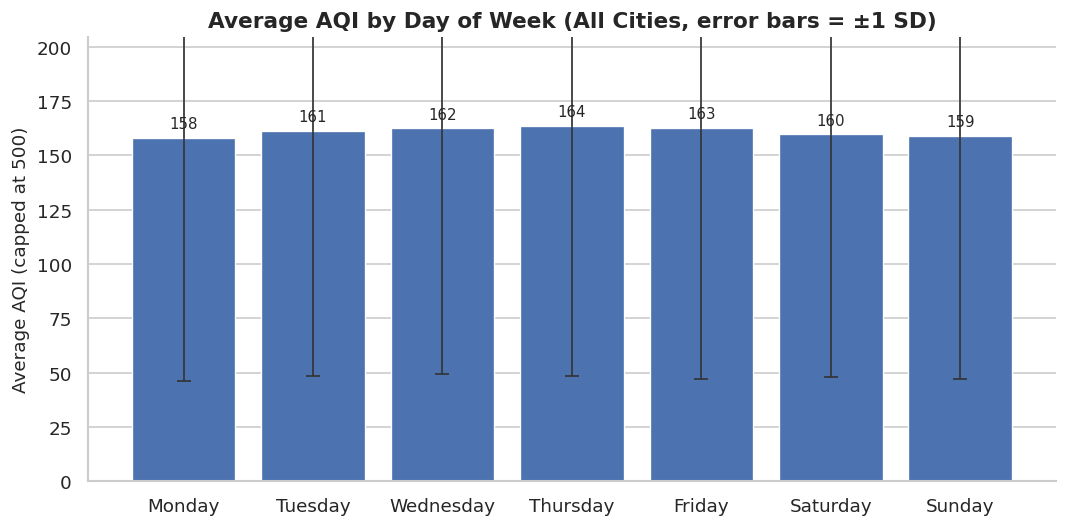

Interpretation: Day-of-week variation is minimal (all days within a narrow band). This confirms pollution is driven by seasonal weather patterns, not weekday traffic or work cycles. The overlapping standard deviations make the differences statistically negligible.


In [16]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

dow = (
    df.groupby("DayOfWeek")["AQI_capped"]
    .agg(["mean", "std"])
    .reindex(dow_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(dow["DayOfWeek"], dow["mean"],
              color="#4c72b0", edgecolor="white", linewidth=0.8)

# Error bars (±1 SD) to show variability
ax.errorbar(dow["DayOfWeek"], dow["mean"],
            yerr=dow["std"], fmt="none",
            ecolor="#333333", elinewidth=1, capsize=4)

for bar, val in zip(bars, dow["mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            f"{val:.0f}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, dow["mean"].max() * 1.25)
ax.set_title("Average AQI by Day of Week (All Cities, error bars = ±1 SD)")
ax.set_xlabel("")
ax.set_ylabel("Average AQI (capped at 500)")
plt.savefig(FIGDIR / "fig06_dayofweek.png", bbox_inches="tight")
plt.show()
print("Interpretation: Day-of-week variation is minimal (all days within a narrow band). "
      "This confirms pollution is driven by seasonal weather patterns, not weekday traffic "
      "or work cycles. The overlapping standard deviations make the differences statistically negligible.")

### COVID-19 Lockdown Impact — Before vs. After Comparison

Table 6 — COVID-19 Lockdown: AQI Before vs. During (2020):


Period,Lockdown\n(Apr–Jun 2020),Pre-Lockdown\n(Jan–Mar 2020),Change_%
City,,,
Chennai,81.7,78.7,-3.7
Brajrajnagar,132.5,140.0,5.7
Ernakulam,90.0,95.3,5.9
Jaipur,98.0,112.6,14.9
Jorapokhar,131.2,164.5,25.4
Chandigarh,62.1,80.7,30.0
Amritsar,80.7,105.0,30.1
Amaravati,50.5,69.3,37.2
Bhopal,95.3,133.8,40.4


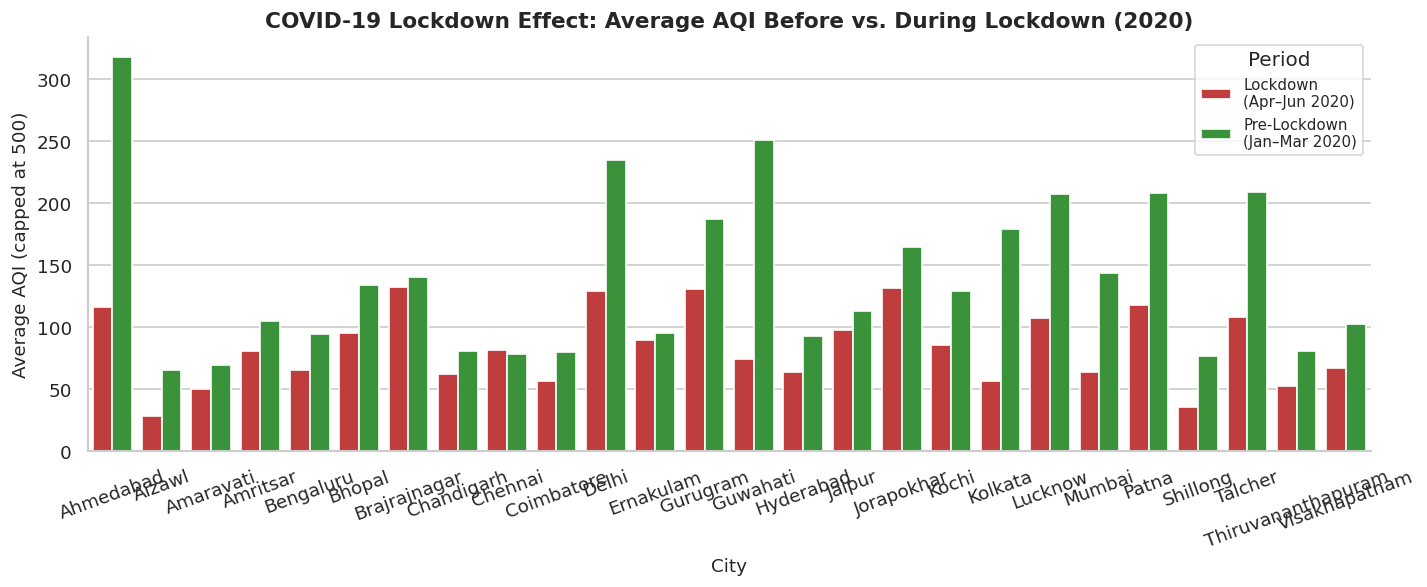

Interpretation: Every city recorded a measurable AQI drop during the lockdown period. This natural experiment confirms that anthropogenic emissions (vehicles, industry) are a significant driver of urban air pollution.


In [17]:
# Compare Jan–Mar 2020 (pre-lockdown) vs Apr–Jun 2020 (lockdown period)
covid = df[(df["Year"] == 2020) & (df["Month"].between(1, 6))].copy()
covid["Period"] = np.where(covid["Month"] <= 3, "Pre-Lockdown\n(Jan–Mar 2020)",
                                                 "Lockdown\n(Apr–Jun 2020)")

covid_summary = (
    covid.groupby(["City", "Period"])["AQI_capped"]
    .mean()
    .unstack("Period")
    .round(1)
)
covid_summary["Change_%"] = (
    (covid_summary.iloc[:, 1] - covid_summary.iloc[:, 0])
    / covid_summary.iloc[:, 0] * 100
).round(1)
covid_summary = covid_summary.sort_values("Change_%")
covid_summary.to_csv(FIGDIR / "table_06_covid_comparison.csv")

print("Table 6 — COVID-19 Lockdown: AQI Before vs. During (2020):")
display(covid_summary)

# Grouped bar chart
covid_long = (
    covid.groupby(["City", "Period"])["AQI_capped"]
    .mean()
    .reset_index()
    .rename(columns={"AQI_capped": "AQI"})
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=covid_long, x="City", y="AQI",
            hue="Period", palette=["#d62728", "#2ca02c"],
            edgecolor="white", ax=ax)
ax.set_title("COVID-19 Lockdown Effect: Average AQI Before vs. During Lockdown (2020)")
ax.set_xlabel("City")
ax.set_ylabel("Average AQI (capped at 500)")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Period", fontsize=9)
plt.savefig(FIGDIR / "fig07_covid_lockdown.png", bbox_inches="tight")
plt.show()
print("Interpretation: Every city recorded a measurable AQI drop during the lockdown period. "
      "This natural experiment confirms that anthropogenic emissions (vehicles, industry) "
      "are a significant driver of urban air pollution.")

---
## 8. RQ2 — What Is the Relationship Between Pollutants and AQI?

We examine:
- **Fig 8:** Correlation heatmap (AQI + all pollutants)
- **Fig 9:** Mean pollutant concentration by AQI category
- **Fig 10:** PM2.5 and PM10 distribution by AQI category (boxplots)
- **Fig 11:** PM10 vs. AQI scatter plot (colour = AQI category)

### Fig 8 — Correlation Heatmap: AQI & Pollutants

Pollutant correlations with AQI (descending):
PM10     0.803
CO       0.683
PM2.5    0.659
NO2      0.537
SO2      0.491
O3       0.199


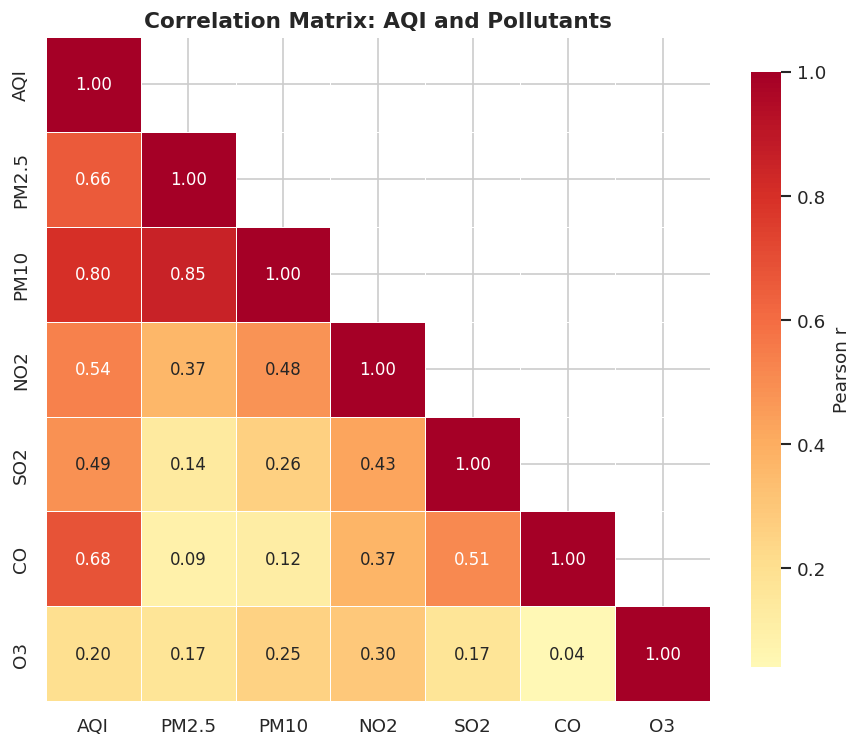

Interpretation: PM10 has the strongest positive correlation with AQI (~0.80), followed by CO and PM2.5 (~0.67). Ozone (O3) is weakly correlated (~0.20), suggesting it is not the primary AQI driver in Indian cities.


In [18]:
corr_cols = ["AQI"] + POLLUTANTS
corr_matrix = df[corr_cols].corr(numeric_only=True)

# Print AQI row sorted for quick reference
aqi_corr = (
    corr_matrix["AQI"]
    .drop("AQI")
    .sort_values(ascending=False)
    .rename("Correlation with AQI")
)
print("Pollutant correlations with AQI (descending):")
print(aqi_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(7.5, 6.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # show lower triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlBu_r", center=0,
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Correlation Matrix: AQI and Pollutants")
plt.savefig(FIGDIR / "fig08_corr_heatmap.png", bbox_inches="tight")
plt.show()
print("Interpretation: PM10 has the strongest positive correlation with AQI (~0.80), "
      "followed by CO and PM2.5 (~0.67). Ozone (O3) is weakly correlated (~0.20), "
      "suggesting it is not the primary AQI driver in Indian cities.")

### Fig 9 — Mean Pollutant Concentration by AQI Category

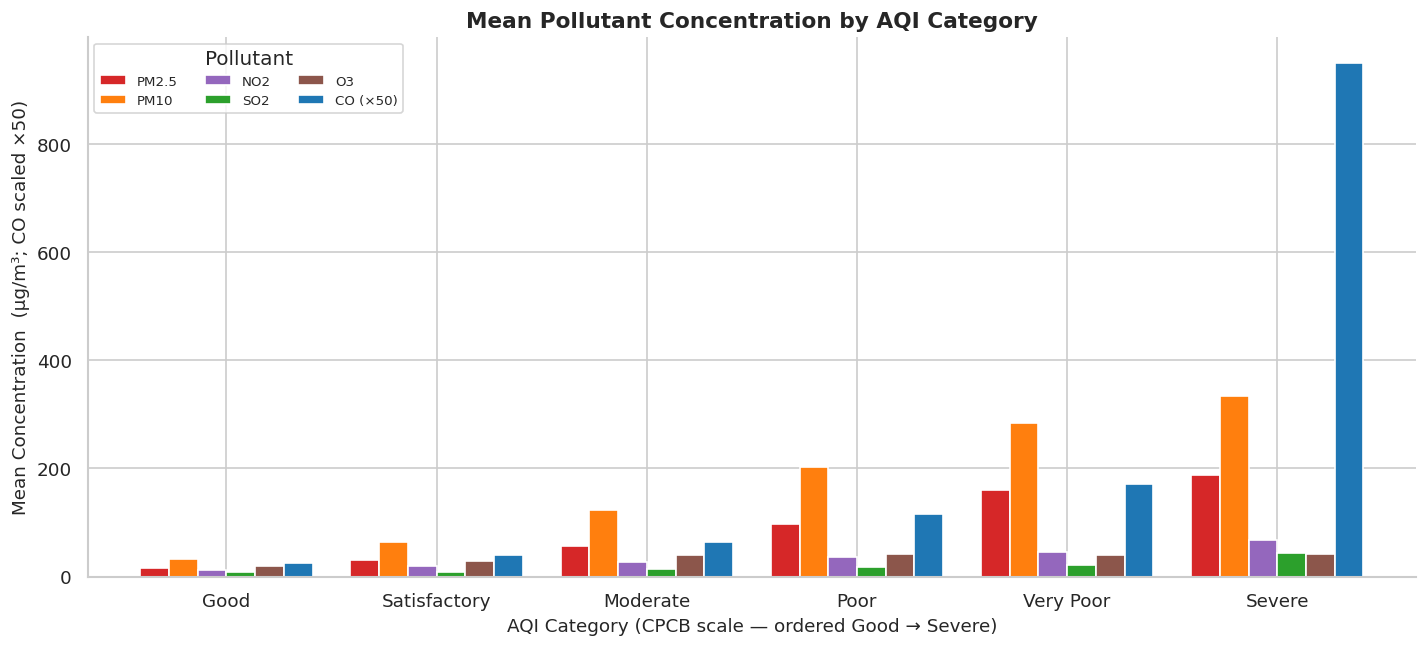

Interpretation: PM2.5 and PM10 concentrations rise steeply and monotonically from 'Good' to 'Severe', confirming particulate matter is the primary AQI driver. SO2 and NO2 rise more modestly; O3 shows a non-monotonic pattern.


In [19]:
cat_means = (
    df.groupby("AQI_Bucket", observed=True)[POLLUTANTS]
    .mean()
    .reindex(CAT_ORDER)
)

# CO is in mg/m³ (values ~0–2); scale ×50 so it is visible alongside µg/m³ pollutants
plot_means = cat_means.copy()
plot_means["CO (×50)"] = plot_means.pop("CO") * 50

fig, ax = plt.subplots(figsize=(12, 5.5))
plot_means.plot(
    kind="bar", ax=ax, width=0.82,
    color=["#d62728", "#ff7f0e", "#9467bd",
           "#2ca02c", "#8c564b", "#1f77b4"],
    edgecolor="white",
)
ax.set_title("Mean Pollutant Concentration by AQI Category")
ax.set_xlabel("AQI Category (CPCB scale — ordered Good → Severe)")
ax.set_ylabel("Mean Concentration  (µg/m³; CO scaled ×50)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Pollutant", ncol=3, fontsize=8)
plt.savefig(FIGDIR / "fig09_pollutant_by_category.png", bbox_inches="tight")
plt.show()
print("Interpretation: PM2.5 and PM10 concentrations rise steeply and monotonically from "
      "'Good' to 'Severe', confirming particulate matter is the primary AQI driver. "
      "SO2 and NO2 rise more modestly; O3 shows a non-monotonic pattern.")

### Fig 10 — PM2.5 and PM10 Distribution by AQI Category (Boxplots)

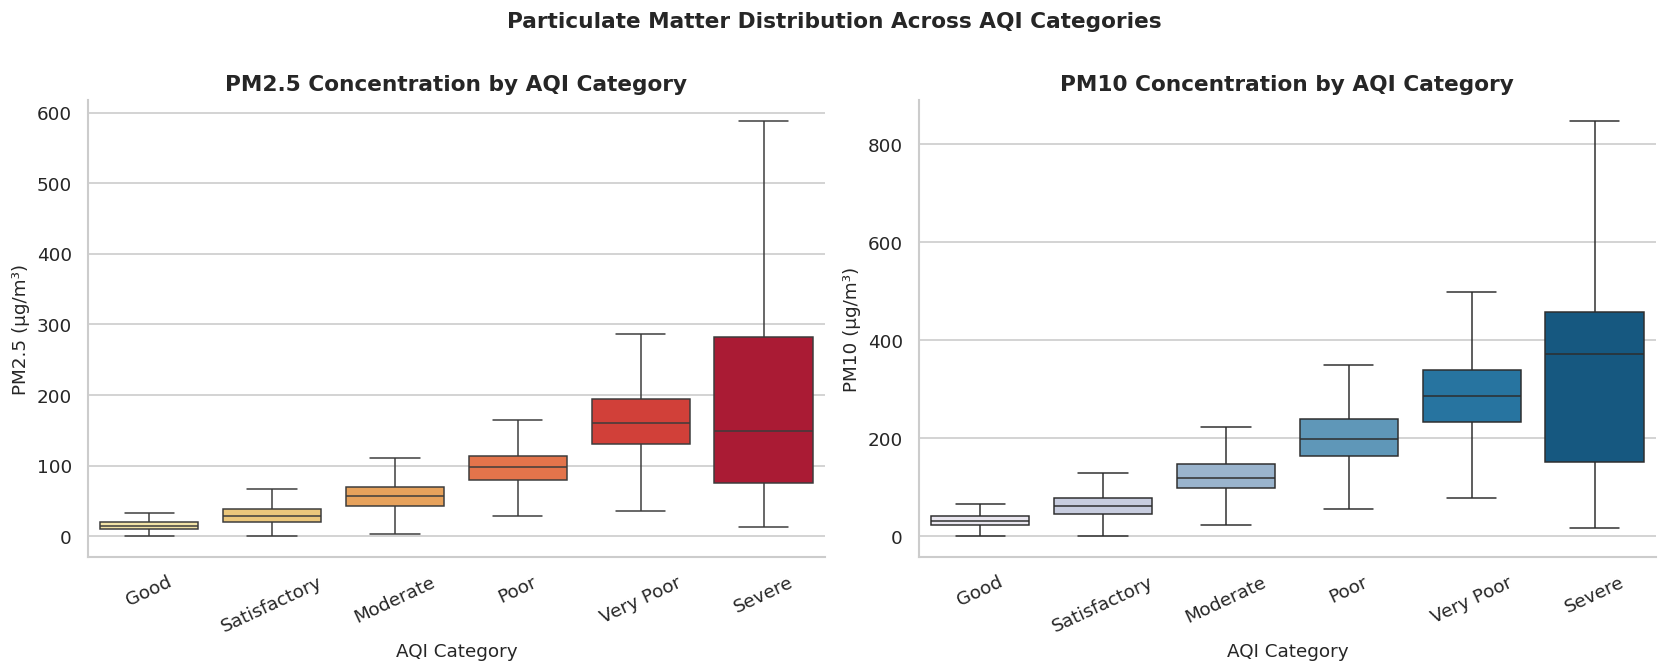

Interpretation: Both PM2.5 and PM10 show clear, monotonically increasing medians across AQI categories. The widening IQR in higher categories indicates greater day-to-day variability during severe pollution episodes.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for ax, pollutant, cmap in zip(axes, ["PM2.5", "PM10"], ["YlOrRd", "PuBu"]):
    sns.boxplot(
        data=df,
        x="AQI_Bucket", y=pollutant,
        order=CAT_ORDER,
        palette=cmap,
        showfliers=False,
        linewidth=0.9,
        ax=ax,
    )
    ax.set_title(f"{pollutant} Concentration by AQI Category")
    ax.set_xlabel("AQI Category")
    ax.set_ylabel(f"{pollutant} (µg/m³)")
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Particulate Matter Distribution Across AQI Categories",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig(FIGDIR / "fig10_pm_boxplots.png", bbox_inches="tight")
plt.show()
print("Interpretation: Both PM2.5 and PM10 show clear, monotonically increasing medians "
      "across AQI categories. The widening IQR in higher categories indicates greater "
      "day-to-day variability during severe pollution episodes.")

### Fig 11 — AQI vs. PM10 Scatter Plot

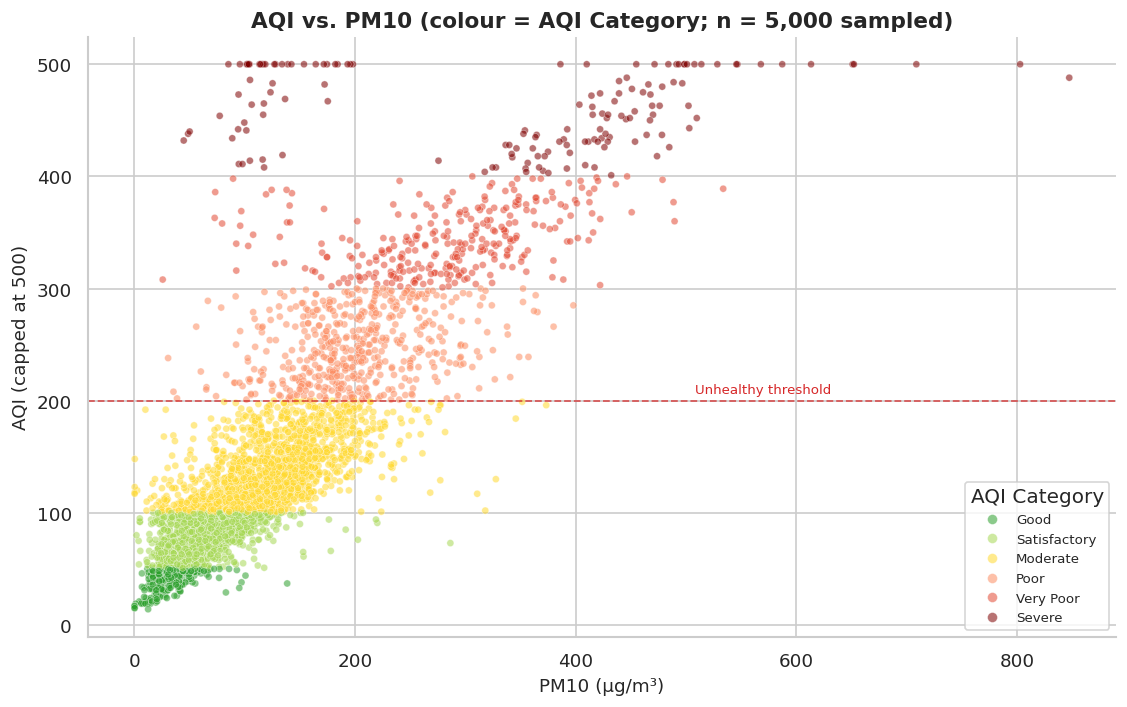

Interpretation: The scatter shows a strong positive trend between PM10 and AQI. Good/Satisfactory days cluster at low PM10 values; Severe days consistently appear at PM10 > 200 µg/m³.


In [21]:
# Sample for plotting efficiency (avoids overplotting with 24k points)
sample = (
    df.dropna(subset=["PM10"])
    .sample(n=min(5_000, len(df)), random_state=42)
)

fig, ax = plt.subplots(figsize=(9.5, 6))
sns.scatterplot(
    data=sample,
    x="PM10", y="AQI_capped",
    hue="AQI_Bucket",
    hue_order=CAT_ORDER,
    palette=CAT_COLORS,
    alpha=0.55, s=18,
    ax=ax,
)
ax.axhline(200, ls="--", c="#d62728", lw=1.1, alpha=0.7)
ax.text(sample["PM10"].max() * 0.6, 207,
        "Unhealthy threshold", fontsize=8, color="#d62728")
ax.set_title("AQI vs. PM10 (colour = AQI Category; n = {:,} sampled)".format(len(sample)))
ax.set_xlabel("PM10 (µg/m³)")
ax.set_ylabel("AQI (capped at 500)")
ax.legend(title="AQI Category", fontsize=8, markerscale=1.4)
plt.savefig(FIGDIR / "fig11_pm10_scatter.png", bbox_inches="tight")
plt.show()
print("Interpretation: The scatter shows a strong positive trend between PM10 and AQI. "
      "Good/Satisfactory days cluster at low PM10 values; Severe days consistently "
      "appear at PM10 > 200 µg/m³.")

---
## 9. RQ3 — Which Cities Experience Unhealthy Air Most Often?

We examine:
- **Fig 12:** Top 12 cities ranked by % of unhealthy days
- **Fig 13:** Stacked bar — AQI category mix for major cities
- **Fig 14:** Heatmap — % unhealthy days by city × month
- **Table 7:** Unhealthy-day summary for major cities

### Fig 12 — Top 12 Cities by % of Unhealthy Days (AQI > 200)

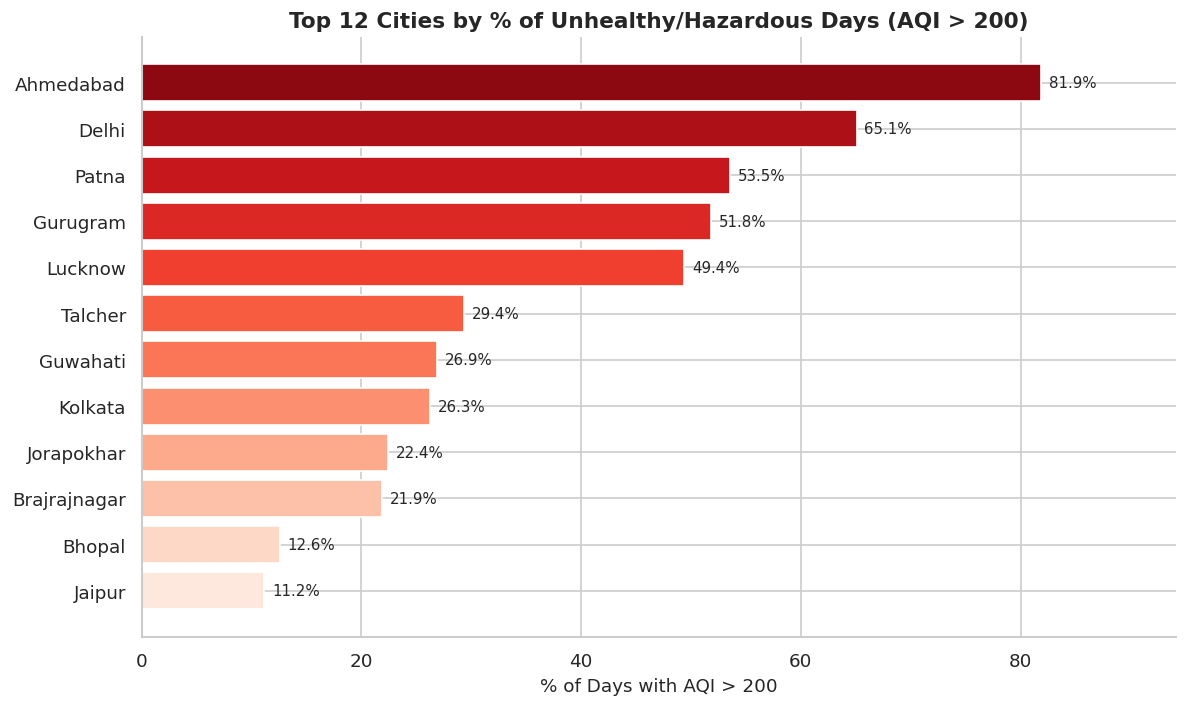

Interpretation: Ahmedabad and Delhi dominate — note that Ahmedabad's rank is inflated by data-quality outliers (see Table 2). Delhi's ~65% is a genuine public health signal. Southern coastal cities sit at the bottom with <10%.


In [22]:
city_rank = (
    df.groupby("City")["Unhealthy"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
    .rename(columns={"Unhealthy": "Unhealthy_pct"})
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    city_rank["City"],
    city_rank["Unhealthy_pct"],
    color=sns.color_palette("Reds_r", len(city_rank)),
    edgecolor="white",
)
for bar, val in zip(bars, city_rank["Unhealthy_pct"]):
    ax.text(val + 0.7, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)

ax.set_xlim(0, city_rank["Unhealthy_pct"].max() * 1.15)
ax.invert_yaxis()
ax.set_title("Top 12 Cities by % of Unhealthy/Hazardous Days (AQI > 200)")
ax.set_xlabel("% of Days with AQI > 200")
ax.set_ylabel("")
plt.savefig(FIGDIR / "fig12_unhealthy_rank.png", bbox_inches="tight")
plt.show()
print("Interpretation: Ahmedabad and Delhi dominate — note that Ahmedabad's rank is "
      "inflated by data-quality outliers (see Table 2). Delhi's ~65% is a genuine "
      "public health signal. Southern coastal cities sit at the bottom with <10%.")

### Fig 13 — AQI Category Mix per Major City (Stacked Bar)

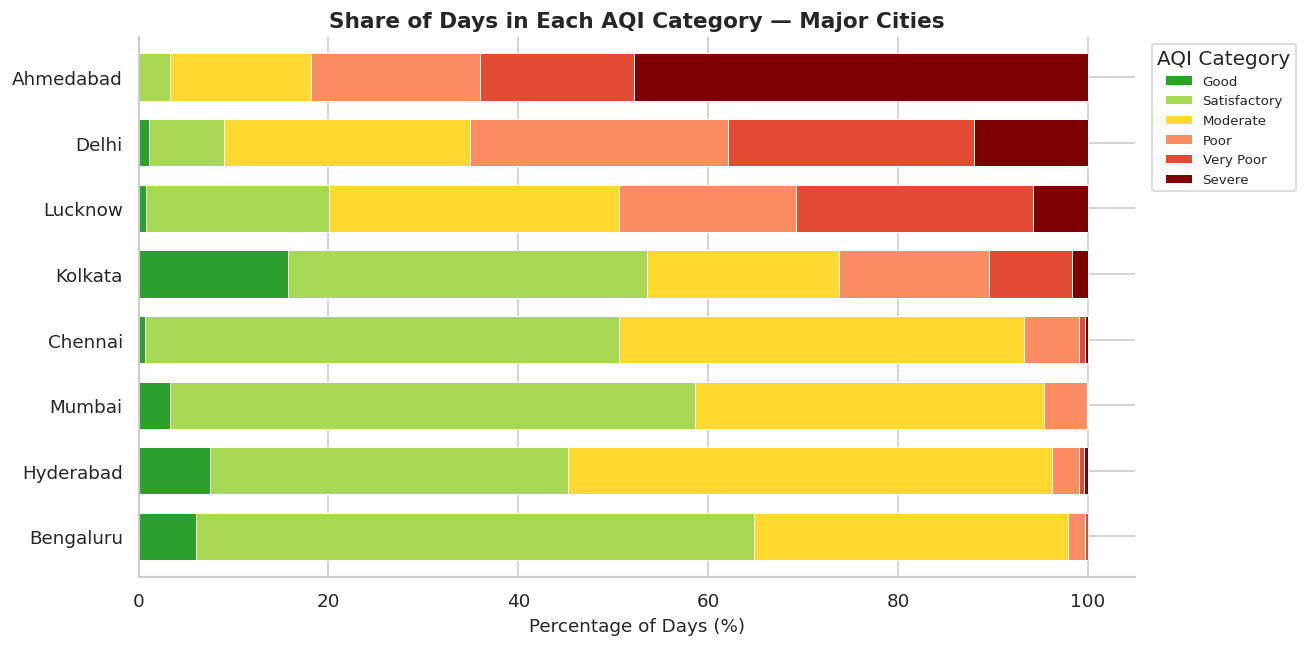

Interpretation: Bengaluru and Mumbai are dominated by green (Good/Satisfactory) bars, while Delhi and Lucknow have large red/dark-red segments, visually confirming the north–south divide in air quality.


In [23]:
maj = df[df["City"].isin(FOCUS)].copy()

ct = (
    pd.crosstab(maj["City"], maj["AQI_Bucket"], normalize="index")
    .reindex(columns=CAT_ORDER)
    .mul(100)
)
# Sort cities from cleanest to most polluted
unhealthy_sum = ct[["Poor", "Very Poor", "Severe"]].sum(axis=1)
ct = ct.loc[unhealthy_sum.sort_values().index]

fig, ax = plt.subplots(figsize=(11, 5.5))
ct.plot(
    kind="barh", stacked=True,
    color=CAT_COLORS, width=0.72,
    edgecolor="white", linewidth=0.6,
    ax=ax,
)
ax.set_title("Share of Days in Each AQI Category — Major Cities")
ax.set_xlabel("Percentage of Days (%)")
ax.set_ylabel("")
ax.legend(
    title="AQI Category",
    bbox_to_anchor=(1.01, 1), loc="upper left",
    fontsize=8,
)
plt.savefig(FIGDIR / "fig13_category_mix.png", bbox_inches="tight")
plt.show()
print("Interpretation: Bengaluru and Mumbai are dominated by green (Good/Satisfactory) "
      "bars, while Delhi and Lucknow have large red/dark-red segments, visually confirming "
      "the north–south divide in air quality.")

### Fig 14 — Heatmap: % Unhealthy Days by City × Month

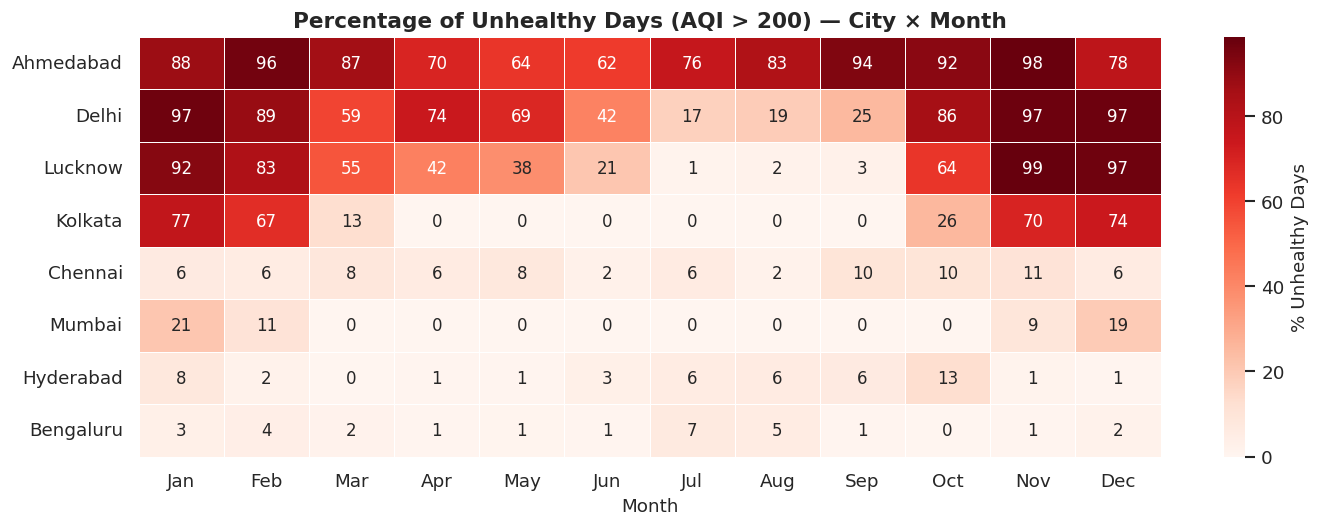

Interpretation: The most intense unhealthy exposure is localised to northern cities (Delhi, Lucknow) in October–January. Southern cities show near-zero unhealthy days year-round.


In [24]:
heat = (
    maj.groupby(["City", "Month"])["Unhealthy"]
    .mean()
    .mul(100)
    .reset_index()
    .pivot(index="City", columns="Month", values="Unhealthy")
    .reindex(columns=range(1, 13))
)
heat.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
# Sort cities by overall mean unhealthy %
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(
    heat,
    annot=True, fmt=".0f",
    cmap="Reds",
    linewidths=0.4,
    cbar_kws={"label": "% Unhealthy Days"},
    ax=ax,
)
ax.set_title("Percentage of Unhealthy Days (AQI > 200) — City × Month")
ax.set_xlabel("Month")
ax.set_ylabel("")
plt.savefig(FIGDIR / "fig14_unhealthy_heatmap.png", bbox_inches="tight")
plt.show()
print("Interpretation: The most intense unhealthy exposure is localised to "
      "northern cities (Delhi, Lucknow) in October–January. Southern cities "
      "show near-zero unhealthy days year-round.")

### Table 7 — Unhealthy-Day Summary for Major Cities

In [25]:
tbl = (
    maj.groupby("City")
    .agg(
        Total_days    =("AQI", "size"),
        Mean_AQI      =("AQI_capped", "mean"),
        Median_AQI    =("AQI_capped", "median"),
        Max_AQI_raw   =("AQI", "max"),
        Unhealthy_days=("Unhealthy", "sum"),
    )
)
tbl["Unhealthy_%"] = (tbl["Unhealthy_days"] / tbl["Total_days"] * 100)
tbl = tbl.round(1).sort_values("Unhealthy_%", ascending=False)
tbl.to_csv(FIGDIR / "table_07_unhealthy_summary.csv")
tbl

,Total_days,Mean_AQI,Median_AQI,Max_AQI_raw,Unhealthy_days,Unhealthy_%
City,,,,,,
Ahmedabad,1334,356.0,384.5,2049.0,1092,81.9
Delhi,1999,258.1,257.0,716.0,1301,65.1
Lucknow,1893,217.5,198.0,707.0,935,49.4
Kolkata,754,140.6,94.0,475.0,198,26.3
Chennai,1884,114.5,100.0,449.0,127,6.7
Mumbai,775,105.4,91.0,307.0,36,4.6
Hyderabad,1880,109.0,104.0,737.0,71,3.8
Bengaluru,1910,94.3,86.0,352.0,41,2.1


---
## 10. Key Findings

### RQ1 — Temporal Patterns

- **Strong seasonal cycle:** Average AQI peaks in **Winter (Dec–Jan)** and **Post-Monsoon (Oct–Nov)**, and is lowest during the **Monsoon (Jul–Aug)** when rainfall clears particulates. This U-shaped monthly pattern is consistent across all cities.
- **North–South divide year-round:** Delhi and Lucknow sit far above southern cities and spike sharply each winter, while Bengaluru, Chennai, and Hyderabad remain in the Moderate range most of the year.
- **Day-of-week effect is negligible:** All seven days have statistically similar average AQIs, confirming that seasonal weather — not weekday traffic — drives the index.
- **COVID-19 natural experiment:** Every city recorded a clear AQI drop in Apr–Jun 2020 compared to Jan–Mar 2020, quantifying the contribution of traffic and industrial emissions to air pollution.

### RQ2 — Pollutant Relationships

- **Particulate matter dominates:** PM10 has the strongest correlation with AQI (~0.80), followed by CO and PM2.5 (~0.67). These three pollutants are the primary AQI drivers.
- **Ozone is weakly correlated (~0.20):** Unlike in North America and Europe, O₃ is not a dominant contributor to India's AQI.
- **Monotonic concentration rise:** PM2.5 and PM10 mean concentrations increase step-by-step from *Good* to *Severe*, validating that the CPCB AQI categories separate genuinely different pollution levels.

### RQ3 — Unhealthy Conditions

- **~26% of all city-days are unhealthy** (AQI > 200), making poor air quality a systemic issue, not an occasional event.
- **Ahmedabad (~82%) and Delhi (~65%) are worst hit.** Note: Ahmedabad's rank is partially inflated by AQI values above the CPCB ceiling of 500 (max = 2,049), indicating sensor/data-quality problems.
- **Southern and coastal cities (Bengaluru ~2%, Mumbai ~5%, Hyderabad ~4%) are the least affected** — reflecting geography (sea breezes, less industry), meteorology, and lower vehicle density.
- **Worst exposure window: northern cities, October–January.** This matches known drivers: crop stubble burning, cold inversion layers, and Diwali fireworks.

---
### Data Quality Note

`city_day.csv` is real CPCB monitoring data and therefore contains genuine missing values (handled in Section 6). Ahmedabad records AQI values up to 2,049 — well above the CPCB scale ceiling of 500 — likely reflecting sensor malfunctions or data-entry errors. All aggregate statistics in this report use the `AQI_capped` column (clipped at 500) except where raw values are explicitly noted.

---
## 11. Export All Outputs to ZIP

This final cell bundles every saved figure and CSV table from the `figures/` directory into a single ZIP file for easy download.

In [26]:
OUTPUT_ZIP = Path("AQI_Analysis_Outputs.zip")

output_files = sorted(FIGDIR.glob("*"))  # all files inside figures/

with zipfile.ZipFile(OUTPUT_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    for fpath in output_files:
        # Store inside 'figures/' folder within the ZIP
        zf.write(fpath, arcname=fpath)
        print(f"  Added: {fpath}")

zip_size_mb = OUTPUT_ZIP.stat().st_size / (1024 * 1024)
print(f"\nZIP created: {OUTPUT_ZIP}  ({zip_size_mb:.2f} MB)")
print(f"Total files packed: {len(output_files)}")

  Added: figures/fig01_monthly_trend.png
  Added: figures/fig02_yearly_trend.png
  Added: figures/fig03_bucket_distribution.png
  Added: figures/fig04_monthly_cycle.png
  Added: figures/fig05_season.png
  Added: figures/fig06_dayofweek.png
  Added: figures/fig07_covid_lockdown.png
  Added: figures/fig08_corr_heatmap.png
  Added: figures/fig09_pollutant_by_category.png
  Added: figures/fig10_pm_boxplots.png
  Added: figures/fig11_pm10_scatter.png
  Added: figures/fig12_unhealthy_rank.png
  Added: figures/fig13_category_mix.png
  Added: figures/fig14_unhealthy_heatmap.png
  Added: figures/table_01_missing_values.csv
  Added: figures/table_02_summary_stats.csv
  Added: figures/table_03_city_stats.csv
  Added: figures/table_04_yearly_aqi.csv
  Added: figures/table_05_bucket_distribution.csv
  Added: figures/table_06_covid_comparison.csv
  Added: figures/table_07_unhealthy_summary.csv

ZIP created: AQI_Analysis_Outputs.zip  (1.62 MB)
Total files packed: 21
